## Module 5: Analyse, diagnose and improve a model​

In the excercise of this week you will be working with financial data in order to (hopefully) find a portfolio of equities which outperform SP500. The data that you are gonna work with has two main sources: 
* Financial data from the companies extracted from the quarterly company reports (mostly extracted from [macrotrends](https://www.macrotrends.net/) so you can use this website to understand better the data and get insights on the features, for example [this](https://www.macrotrends.net/stocks/charts/AAPL/apple/revenue) is the one corresponding to APPLE)
* Stock prices, mostly extracted from [morningstar](https://indexes.morningstar.com/page/morningstar-indexes-empowering-investor-success?utm_source=google&utm_medium=cpc&utm_campaign=MORNI%3AG%3ASearch%3ABrand%3ACore%3AUK%20MORNI%3ABrand%3ACore%3ABroad&utm_content=engine%3Agoogle%7Ccampaignid%3A18471962329%7Cadid%3A625249340069&utm_term=morningstar%20index&gclid=CjwKCAjws9ipBhB1EiwAccEi1Fu6i20XHVcxFxuSEtJGF0If-kq5-uKnZ3rov3eRkXXFfI5j8QBtBBoCayEQAvD_BwE), which basically tell us how the stock price is evolving so we can use it both as past features and the target to predict).

Before going to the problem that we want to solve, let's comment some of the columns of the dataset:


* `Ticker`: a [short name](https://en.wikipedia.org/wiki/Ticker_symbol) to identify the equity (that you can use to search in macrotrends)
* `date`: the date of the company report (normally we are gonna have 1 every quarter). This is for informative purposes but you can ignore it when modeling.
* `execution date`: the date when we would had executed the algorithm for that equity. We want to execute the algorithm once per quarter to create the portfolio, but the release `date`s of all the different company reports don't always match for the quarter, so we just take a common `execution_date` for all of them.
* `stock_change_div_365`: what is the % change of the stock price (with dividens) in the FOLLOWING year after `execution date`. 
* `sp500_change_365`: what is the % change of the SP500 in the FOLLOWING year after `execution date`.
* `close_0`: what is the price at the moment of `execution date`
* `stock_change__minus_120` what is the % change of the stock price in the last 120 days
* `stock_change__minus_730`: what is the % change of the stock price in the last 730 days

The rest of the features can be divided beteween financial features (the ones coming from the reports) and technical features (coming from the stock price). We leave the technical features here as a reference: 

In [1]:
technical_features = ['close_0', 'close_sp500_0', 'close_365', 'close_sp500_365',
       'close__minus_120', 'close_sp500__minus_120', 'close__minus_365',
       'close_sp500__minus_365', 'close__minus_730', 'close_sp500__minus_730',
       'stock_change_365','stock_change_div_365', 'sp500_change_365', 'stock_change__minus_120',
       'sp500_change__minus_120', 'stock_change__minus_365',
       'sp500_change__minus_365', 'stock_change__minus_730','sp500_change__minus_730',
       'std__minus_365','std__minus_730','std__minus_120']

The problem that we want to solve is basically find a portfolio of `top_n` tickers (initially set to 10) to invest every `execution date` (basically once per quarter) and the goal is to have a better return than `SP500` in the following year. The initial way to model this is to have a binary target which is 1 when `stock_change_div_365` - `sp500_change_365` (the difference between the return of the equity and the SP500 in the following year) is positive or 0 otherwise. So we try to predict the probability of an equity of improving SP500 in the following year, we take the `top_n` equities and compute their final return.

In [2]:
import pandas as pd
import re
import numpy as np
import lightgbm as lgb
from plotnine import ggplot, geom_histogram, aes, geom_col, coord_flip,geom_bar,scale_x_discrete, geom_point, theme,element_text

In [3]:
# number of trees in lightgbm
n_trees = 40
minimum_number_of_tickers = 1500
# Number of the quarters in the past to train
n_train_quarters = 36
# number of tickers to make the portfolio
top_n = 10

In [4]:
data_set = pd.read_feather("data/financials_against_return.feather")

Remove these quarters which have les than `minimum_number_of_tickers` tickers:

In [5]:
df_quarter_lengths = data_set.groupby(["execution_date"]).size().reset_index().rename(columns = {0:"count"})
data_set = pd.merge(data_set, df_quarter_lengths, on = ["execution_date"])
data_set = data_set[data_set["count"]>=minimum_number_of_tickers]

In [6]:
data_set.shape

(170483, 145)

Create the target:

In [7]:
data_set["diff_ch_sp500"] = data_set["stock_change_div_365"] - data_set["sp500_change_365"]

data_set.loc[data_set["diff_ch_sp500"]>0,"target"] = 1
data_set.loc[data_set["diff_ch_sp500"]<0,"target"] = 0

data_set["target"].value_counts()

target
0.0    82437
1.0    73829
Name: count, dtype: int64

This function computes the main metric that we want to optimize: given a prediction where we have probabilities for each equity, we sort the equities in descending order of probability, we pick the `top_n` ones, and we we weight the returned `diff_ch_sp500` by the probability:

In [8]:
def get_weighted_performance_of_stocks(df,metric):
    df["norm_prob"] = 1/len(df)
    return np.sum(df["norm_prob"]*df[metric])

def get_top_tickers_per_prob(preds):
    if len(preds) == len(train_set):
        data_set = train_set.copy()
    elif len(preds) == len(test_set):
        data_set = test_set.copy()
    else:
        assert ("Not matching train/test")
    data_set["prob"] = preds
    data_set = data_set.sort_values(["prob"], ascending = False)
    data_set = data_set.head(top_n)
    return data_set

# main metric to evaluate: average diff_ch_sp500 of the top_n stocks
def top_wt_performance(preds, train_data):
    top_dataset = get_top_tickers_per_prob(preds)
    return "weighted-return", get_weighted_performance_of_stocks(top_dataset,"diff_ch_sp500"), True

We have created for you a function to make the `train` and `test` split based on a `execution_date`:

In [9]:
def split_train_test_by_period(data_set, test_execution_date,include_nulls_in_test = False):
    # we train with everything happening at least one year before the test execution date
    train_set = data_set.loc[data_set["execution_date"] <= pd.to_datetime(test_execution_date) - pd.Timedelta(350, unit = "day")]
    # remove those rows where the target is null
    train_set = train_set[~pd.isna(train_set["diff_ch_sp500"])]
    execution_dates = train_set.sort_values("execution_date")["execution_date"].unique()
    # Pick only the last n_train_quarters
    if n_train_quarters!=None:
        train_set = train_set[train_set["execution_date"].isin(execution_dates[-n_train_quarters:])]
        
    # the test set are the rows happening in the execution date with the concrete frequency
    test_set = data_set.loc[(data_set["execution_date"] == test_execution_date)]
    if not include_nulls_in_test:
        test_set = test_set[~pd.isna(test_set["diff_ch_sp500"])]
    test_set = test_set.sort_values('date', ascending = False).drop_duplicates('Ticker', keep = 'first')
    
    return train_set, test_set

Ensure that we don't include features which are irrelevant or related to the target:

In [33]:
def get_columns_to_remove():
    columns_to_remove = [
                         "date",
                         "improve_sp500",
                         "Ticker",
                         "freq",
                         "set",
                         "close_sp500_365",
                         "close_365",
                         "stock_change_365",
                         "sp500_change_365",
                         "stock_change_div_365",
                         "stock_change_730",
                         "sp500_change_365",
                         "stock_change_div_730",
                         "diff_ch_sp500",
                         "diff_ch_avg_500",
                         "execution_date","target","index","quarter","std_730","count",]
        
    return columns_to_remove

This is the main modeling function, it receives a train test and a test set and trains a `lightgbm` in classification mode. We don't recommend to change the main algorithm for this excercise but we suggest to play with its hyperparameters:

In [34]:
import warnings
warnings.filterwarnings('ignore')


def train_model(train_set,test_set,n_estimators = 300):

    columns_to_remove = get_columns_to_remove()
    
    X_train = train_set.drop(columns = columns_to_remove, errors = "ignore")
    X_test = test_set.drop(columns = columns_to_remove, errors = "ignore")
    
    
    y_train = train_set["target"]
    y_test = test_set["target"]

    lgb_train = lgb.Dataset(X_train,y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)
    
    eval_result = {}
    
 
    objective = 'binary'
    metric = 'binary_logloss' 
    params = {
             "random_state":1, 
             "verbosity": -1,
             "n_jobs":10, 
             "n_estimators":n_estimators,
             "objective": objective,
             "metric": metric}
    
    model = lgb.train(params = params,train_set = lgb_train,
                      valid_sets = [lgb_test,lgb_train],
                      feval = [top_wt_performance],
                      callbacks = [lgb.record_evaluation(eval_result = eval_result)])
    return model,eval_result,X_train,X_test


 
            

This is the function which receives an `execution_date` and splits the dataset between train and test, trains the models and evaluates the model in test. It returns a dictionary with the different evaluation metrics in train and test:

In [35]:
def run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_estimators,include_nulls_in_test = False):
        global train_set
        global test_set
        # split the dataset between train and test
        train_set, test_set = split_train_test_by_period(data_set,execution_date,include_nulls_in_test = include_nulls_in_test)
        train_size, _ = train_set.shape
        test_size, _ = test_set.shape
        model = None
        X_train = None
        X_test = None
        
        # if both train and test are not empty
        if train_size > 0 and test_size>0:
            model, evals_result, X_train, X_test = train_model(train_set,
                                                              test_set,
                                                              n_estimators = n_estimators)
            
            test_set['prob'] = model.predict(X_test)
            predicted_tickers = test_set.sort_values('prob', ascending = False)
            predicted_tickers["execution_date"] = execution_date
            all_results[(execution_date)] = evals_result
            all_models[(execution_date)] = model
            all_predicted_tickers_list.append(predicted_tickers)
        return all_results,all_predicted_tickers_list,all_models,model,X_train,X_test


execution_dates = np.sort( data_set['execution_date'].unique() )


This is the main training loop: it goes through each different `execution_date` and calls `run_model_for_execution_date`. All the results are stored in `all_results` and the predictions in `all_predicted_tickers_list`.

In [32]:
all_results = {}
all_predicted_tickers_list = []
all_models = {}

for execution_date in execution_dates:
    print(execution_date)
    all_results,all_predicted_tickers_list,all_models,model,X_train,X_test = run_model_for_execution_date(execution_date,all_results,all_predicted_tickers_list,all_models,n_trees,False)
all_predicted_tickers = pd.concat(all_predicted_tickers_list)
#tarda en cargar muchísimo

2005-06-30T00:00:00.000000000
2005-09-30T00:00:00.000000000
2005-12-30T00:00:00.000000000
2006-03-31T00:00:00.000000000
2006-06-30T00:00:00.000000000
2006-09-30T00:00:00.000000000
2006-12-30T00:00:00.000000000
2007-03-31T00:00:00.000000000
2007-06-30T00:00:00.000000000


KeyboardInterrupt: 

In [14]:
def parse_results_into_df(set_):
    df = pd.DataFrame()
    for date in all_results:
        df_tmp = pd.DataFrame(all_results[(date)][set_])
        df_tmp["n_trees"] = list(range(len(df_tmp)))
        df_tmp["execution_date"] = date
        df= pd.concat([df,df_tmp])
    
    df["execution_date"] = df["execution_date"].astype(str)
    
    return df

In [15]:
test_results = parse_results_into_df("valid_0")
train_results = parse_results_into_df("training")

In [16]:
test_results_final_tree = test_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")
train_results_final_tree = train_results.sort_values(["execution_date","n_trees"]).drop_duplicates("execution_date",keep = "last")


And this are the results:

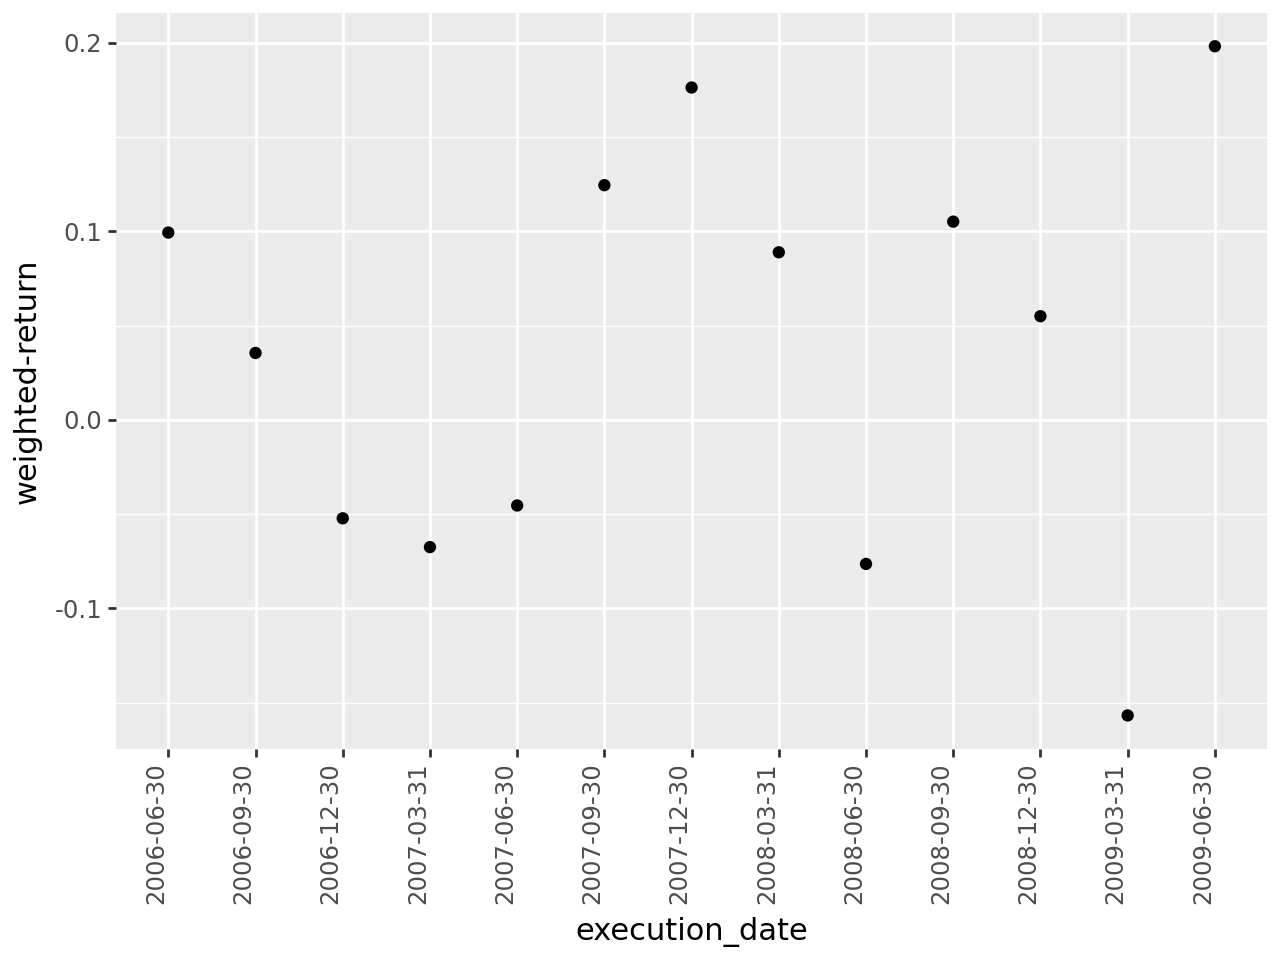

In [17]:
ggplot(test_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))



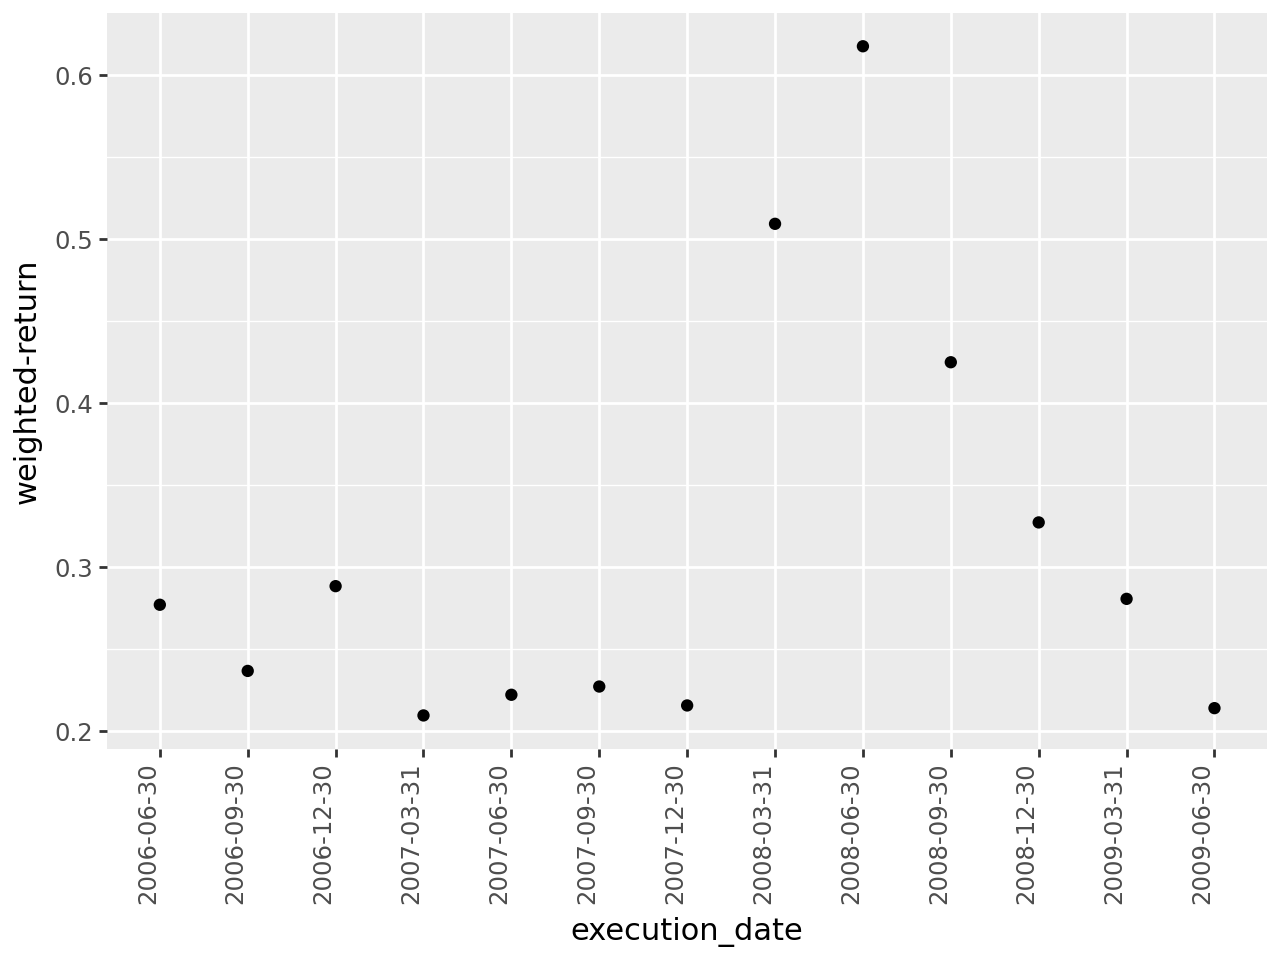

In [18]:
ggplot(train_results_final_tree) + geom_point(aes(x = "execution_date", y = "weighted-return")) + theme(axis_text_x = element_text(angle = 90, vjust = 0.5, hjust=1))


We have trained the first models for all the periods for you, but there are a lot of things which may be wrong or can be improved. Some ideas where you can start:
* Try to see if there is any kind of data leakage or suspicious features
* If the training part is very slow, try to see how you can modify it to execute faster tests
* Try to understand if the algorithm is learning correctly
* We are using a very high level metric to evaluate the algorithm so you maybe need to use some more low level ones
* Try to see if there is overfitting
* Try to see if there is a lot of noise between different trainings
* To simplify, why if you only keep the first tickers in terms of Market Cap?
* Change the number of quarters to train in the past

This function can be useful to compute the feature importance:

In [19]:
def draw_feature_importance(model,top = 15):
    fi = model.feature_importance()
    fn = model.feature_name()
    feature_importance = pd.DataFrame([{"feature":fn[i],"imp":fi[i]} for i in range(len(fi))])
    feature_importance = feature_importance.sort_values("imp",ascending = False).head(top)
    feature_importance = feature_importance.sort_values("imp",ascending = True)
    plot = ggplot(feature_importance,aes(x = "feature",y  = "imp")) + geom_col(fill = "lightblue") + coord_flip() +  scale_x_discrete(limits = feature_importance["feature"])
    return plot


In [20]:
from scipy.stats import lognorm
import matplotlib.pyplot as plt

In [41]:
# Posible Data Lackage
# Estoy usando info del futuro con: close_365 stockchange_365, sp500_change_365
def check_data_leakage(df, execution_date):
    """
    Verifica si hay features que contienen información del futuro
    """
    print("=" * 60)
    print(f"VERIFICANDO LEAKAGE PARA: {execution_date}")
    print("=" * 60)

    # 1. Features sospechosas que contienen información futura
    suspicious_features = [
        'close_365',           # Precio a 365 días (FUTURO)
        'close_sp500_365',     # SP500 a 365 días (FUTURO)
        'stock_change_365',    # Cambio a 365 días (FUTURO)
        'stock_change_div_365', # Cambio con dividendos (FUTURO)
        'sp500_change_365',    # Cambio SP500 (FUTURO)
        'stock_change_730',    # Cambio a 730 días (FUTURO)
        'stock_change_div_730', # Cambio con dividendos 730 (FUTURO)
    ]

    print("\n🔍 FEATURES SOSPECHOSAS ENCONTRADAS:")
    for feat in suspicious_features:
        if feat in df.columns:
            print(f"    {feat} - ELIMINAR (contiene info futura)")

    # 2. Features que SÍ deberían estar (históricas)
    safe_features = [
        'close_0',              # Precio actual (OK)
        'close__minus_120',     # Precio hace 120 días (OK)
        'close__minus_365',     # Precio hace 365 días (OK)
        'close__minus_730',     # Precio hace 730 días (OK)
        'stock_change__minus_120', # Cambio histórico (OK)
        'stock_change__minus_365', # Cambio histórico (OK)
        'stock_change__minus_730', # Cambio histórico (OK)
        'std__minus_365',       # Volatilidad histórica (OK)
        'std__minus_730',       # Volatilidad histórica (OK)
    ]

    print("\n FEATURES SEGURAS (históricas):")
    for feat in safe_features:
        if feat in df.columns:
            print(f"  ✓  {feat}")

    # 3. Verificar correlación con target
    if 'diff_ch_sp500' in df.columns:
        correlations = []
        for feat in suspicious_features:
            if feat in df.columns:
                corr = df[[feat, 'diff_ch_sp500']].corr().iloc[0, 1]
                correlations.append((feat, abs(corr)))

        if correlations:
            print("\n  CORRELACIONES CON TARGET (diff_ch_sp500):")
            for feat, corr in sorted(correlations, key=lambda x: x[1], reverse=True):
                status = " ALTA" if corr > 0.3 else "  MEDIA" if corr > 0.1 else "✓ BAJA"
                print(f"  {status}: {feat:30s} -> {corr:.4f}")

    return suspicious_features

# Uso
suspicious = check_data_leakage(data_set, data_set['execution_date'].iloc[0])

print("\n" + "=" * 60)
print("RECOMENDACIÓN:")
print("=" * 60)
print("Añade estas features a 'columns_to_remove':")
for feat in suspicious:
    print(f"  '{feat}',")

VERIFICANDO LEAKAGE PARA: 2005-06-30 00:00:00

🔍 FEATURES SOSPECHOSAS ENCONTRADAS:
    stock_change_365 - ELIMINAR (contiene info futura)
    stock_change_div_365 - ELIMINAR (contiene info futura)
    sp500_change_365 - ELIMINAR (contiene info futura)
    stock_change_730 - ELIMINAR (contiene info futura)
    stock_change_div_730 - ELIMINAR (contiene info futura)

 FEATURES SEGURAS (históricas):
  ✓  close_0
  ✓  stock_change__minus_120
  ✓  stock_change__minus_365
  ✓  stock_change__minus_730
  ✓  std__minus_365
  ✓  std__minus_730

  CORRELACIONES CON TARGET (diff_ch_sp500):
   ALTA: stock_change_div_365           -> 0.9997
   ALTA: stock_change_365               -> 0.9997
   ALTA: stock_change_730               -> 0.5508
   ALTA: stock_change_div_730           -> 0.5508
  ✓ BAJA: sp500_change_365               -> 0.0103

RECOMENDACIÓN:
Añade estas features a 'columns_to_remove':
  'close_365',
  'close_sp500_365',
  'stock_change_365',
  'stock_change_div_365',
  'sp500_change_365',

In [36]:
# Ahora elimino las variables sugeridas arriba, cambio el nª de árboles a 200 y reentreno

In [37]:
# Análisis de overfitting (la métrica en train es mucho mayor que en test)
# Causas posibles: nº de árboles (40 es pequeño), posibles features ruidosas, falta de regularización
import pandas as pd
import numpy as np
from plotnine import *

def analyze_overfitting(train_results, test_results):
    """
    Analiza el overfitting comparando train vs test
    """
    print("=" * 70)
    print("ANÁLISIS DE OVERFITTING")
    print("=" * 70)

    # 1. Comparar métricas finales
    train_final = train_results.groupby('execution_date')['weighted-return'].last()
    test_final = test_results.groupby('execution_date')['weighted-return'].last()

    comparison = pd.DataFrame({
        'train': train_final,
        'test': test_final
    })
    comparison['gap'] = comparison['train'] - comparison['test']
    comparison['gap_pct'] = (comparison['gap'] / comparison['train'].abs()) * 100

    print("\n📊 ESTADÍSTICAS TRAIN vs TEST:")
    print(f"  Train mean:  {comparison['train'].mean():>8.4f}")
    print(f"  Test mean:   {comparison['test'].mean():>8.4f}")
    print(f"  Gap mean:    {comparison['gap'].mean():>8.4f}")
    print(f"  Gap % mean:  {comparison['gap_pct'].mean():>8.2f}%")

    # 2. Detectar overfitting severo
    severe_overfit = comparison[comparison['gap_pct'] > 50]
    print(f"\n  Períodos con OVERFITTING SEVERO (gap > 50%): {len(severe_overfit)}")
    if len(severe_overfit) > 0:
        print(severe_overfit[['train', 'test', 'gap_pct']].head())

    # 3. Visualización
    comparison_long = comparison.reset_index().melt(
        id_vars=['execution_date'],
        value_vars=['train', 'test'],
        var_name='set',
        value_name='return'
    )
    comparison_long['execution_date'] = comparison_long['execution_date'].astype(str)

    plot = (ggplot(comparison_long, aes(x='execution_date', y='return', color='set')) +
            geom_point(size=2) +
            geom_line(aes(group='set')) +
            theme(axis_text_x=element_text(angle=90, hjust=1)) +
            labs(title='Train vs Test Performance',
                 y='Weighted Return',
                 x='Execution Date') +
            scale_color_manual(values=['#2ecc71', '#e74c3c']))

    print("\n RECOMENDACIONES:")
    if comparison['gap_pct'].mean() > 30:
        print("   OVERFITTING DETECTADO")
        print("     - Aumenta n_trees (40 -> 100-200)")
        print("     - Añade regularización (max_depth, min_child_samples)")
        print("     - Reduce features ruidosas")
    elif comparison['gap_pct'].mean() > 15:
        print("    Overfitting moderado")
        print("     - Considera aumentar n_trees")
        print("     - Revisa feature importance")
    else:
        print("   Generalización aceptable")

    return comparison, plot

# Uso
comparison_df, overfitting_plot = analyze_overfitting(
    train_results_final_tree,
    test_results_final_tree
)
print(overfitting_plot)

ANÁLISIS DE OVERFITTING

📊 ESTADÍSTICAS TRAIN vs TEST:
  Train mean:    0.3117
  Test mean:     0.0373
  Gap mean:      0.2744
  Gap % mean:     84.61%

  Períodos con OVERFITTING SEVERO (gap > 50%): 10
                   train      test     gap_pct
execution_date                                
2006-06-30      0.277172  0.099404   64.136485
2006-09-30      0.236828  0.035528   84.998218
2006-12-30      0.288516 -0.052195  118.090768
2007-03-31      0.209679 -0.067471  132.178056
2007-06-30      0.222281 -0.045395  120.422545

 RECOMENDACIONES:
   OVERFITTING DETECTADO
     - Aumenta n_trees (40 -> 100-200)
     - Añade regularización (max_depth, min_child_samples)
     - Reduce features ruidosas
<ggplot: (640 x 480)>


In [23]:
# Funciones de mejora
# Función de entrenamiento mejorada con regularización
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

def train_model_improved(train_set, test_set, n_estimators=200):
    """
    Versión mejorada con regularización y más árboles
    """
    columns_to_remove = get_columns_to_remove()

    # CRÍTICO: Añadir features futuras que causan leakage
    columns_to_remove.extend([
        'close_365',
        'close_sp500_365',
        'stock_change_365',
        'stock_change_div_365',
        'stock_change_730',
        'stock_change_div_730',
        'sp500_change_365'
    ])

    X_train = train_set.drop(columns=columns_to_remove, errors="ignore")
    X_test = test_set.drop(columns=columns_to_remove, errors="ignore")

    y_train = train_set["target"]
    y_test = test_set["target"]

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

    eval_result = {}

    # Parámetros mejorados con regularización
    params = {
        "random_state": 1,
        "verbosity": -1,
        "n_jobs": 10,
        "n_estimators": n_estimators,  # Aumentado de 40 -> 200
        "objective": 'binary',
        "metric": 'binary_logloss',

        # NUEVOS: Regularización para prevenir overfitting
        "max_depth": 6,              # Limita profundidad
        "min_child_samples": 20,     # Min muestras por hoja
        "subsample": 0.8,            # Bagging
        "colsample_bytree": 0.8,     # Feature sampling
        "reg_alpha": 0.1,            # L1 regularization
        "reg_lambda": 0.1,           # L2 regularization
        "learning_rate": 0.05,       # Más conservador
    }

    model = lgb.train(
        params=params,
        train_set=lgb_train,
        valid_sets=[lgb_test, lgb_train],
        feval=[top_wt_performance],
        callbacks=[lgb.record_evaluation(eval_result=eval_result)]
    )

    return model, eval_result, X_train, X_test

# Comparación rápida
print("COMPARACIÓN DE HIPERPARÁMETROS:")
print("\n VERSIÓN ORIGINAL:")
print("  - n_trees: 40 (MUY BAJO)")
print("  - Sin regularización")
print("  - Learning rate: default (0.1)")
print("\n VERSIÓN MEJORADA:")
print("  - n_trees: 200")
print("  - max_depth: 6")
print("  - min_child_samples: 20")
print("  - subsample: 0.8")
print("  - learning_rate: 0.05")
print("  - L1/L2 regularization: 0.1")

COMPARACIÓN DE HIPERPARÁMETROS:

📉 VERSIÓN ORIGINAL:
  - n_trees: 40 (MUY BAJO)
  - Sin regularización
  - Learning rate: default (0.1)

📈 VERSIÓN MEJORADA:
  - n_trees: 200
  - max_depth: 6
  - min_child_samples: 20
  - subsample: 0.8
  - learning_rate: 0.05
  - L1/L2 regularization: 0.1


In [38]:
# Análisis completo de features
import pandas as pd
import numpy as np
from plotnine import *

def analyze_features(model, X_train, top=20):
    """
    Análisis detallado de feature importance
    """
    print("=" * 70)
    print("ANÁLISIS DE FEATURES")
    print("=" * 70)

    # 1. Feature importance
    fi = model.feature_importance()
    fn = model.feature_name()

    feature_importance = pd.DataFrame({
        "feature": fn,
        "importance": fi
    })
    feature_importance = feature_importance.sort_values("importance", ascending=False)

    # 2. Separar por tipo de feature
    technical_patterns = ['close', 'stock_change', 'sp500', 'std']
    feature_importance['type'] = 'Financial'
    for pattern in technical_patterns:
        mask = feature_importance['feature'].str.contains(pattern, case=False)
        feature_importance.loc[mask, 'type'] = 'Technical'

    print("\n TOP 20 FEATURES MÁS IMPORTANTES:")
    print(feature_importance.head(20).to_string(index=False))

    # 3. Distribución por tipo
    print("\n IMPORTANCIA POR TIPO:")
    type_summary = feature_importance.groupby('type')['importance'].agg(['sum', 'mean', 'count'])
    print(type_summary)

    # 4. Features sospechosas en top
    suspicious = ['365', '730']
    top_features = feature_importance.head(20)
    suspicious_in_top = []
    for feat in top_features['feature']:
        if any(s in feat for s in suspicious):
            suspicious_in_top.append(feat)

    if suspicious_in_top:
        print("\n  FEATURES SOSPECHOSAS EN TOP 20:")
        for feat in suspicious_in_top:
            print(f"  - {feat}")

    # 5. Visualización
    top_feats = feature_importance.head(top).copy()
    top_feats = top_feats.sort_values("importance", ascending=True)

    plot = (ggplot(top_feats, aes(x='feature', y='importance', fill='type')) +
            geom_col() +
            coord_flip() +
            scale_x_discrete(limits=top_feats['feature']) +
            labs(title=f'Top {top} Most Important Features',
                 x='Feature',
                 y='Importance') +
            theme(figure_size=(10, 8)))

    # 6. Recomendaciones
    print("\n RECOMENDACIONES:")
    if suspicious_in_top:
        print("   Hay features futuras en top importance!")
        print("     -> CRÍTICO: Elimínalas del modelo")

    tech_pct = (type_summary.loc['Technical', 'sum'] /
                feature_importance['importance'].sum() * 100)
    if tech_pct > 70:
        print(f"    Features técnicas dominan ({tech_pct:.1f}%)")
        print("     -> Considera añadir más features financieras")

    return feature_importance, plot

In [54]:
# Pipeline completo de análisis y mejora
import pandas as pd
import numpy as np
from plotnine import *

def complete_analysis_pipeline(data_set, execution_dates, n_trees=200):
    """
    Pipeline completo: leakage check -> train -> analyze
    """
    print("=" * 70)
    print(" INICIANDO PIPELINE COMPLETO DE ANÁLISIS")
    print("=" * 70)

    # PASO 1: Verificar leakage
    print("\n PASO 1: Verificando Data Leakage...")
    suspicious = check_data_leakage(data_set, execution_dates[0])

    # PASO 2: Entrenar con modelo mejorado (solo un período de prueba)
    print("\n PASO 2: Entrenando modelo mejorado...")
    test_date = execution_dates[-5]  # Penúltima fecha para testing

    global train_set, test_set
    train_set, test_set = split_train_test_by_period(
        data_set, test_date, include_nulls_in_test=False
    )

    print(f"  Train size: {len(train_set):,}")
    print(f"  Test size: {len(test_set):,}")

    model, evals_result, X_train, X_test = train_model_improved(
        train_set, test_set, n_estimators=n_trees
    )

    # PASO 3: Analizar features
    print("\n PASO 3: Analizando Features...")
    feature_df, feature_plot = analyze_features(model, X_train, top=20)

    # PASO 4: Evaluar predicciones
    print("\n PASO 4: Evaluando Predicciones...")
    test_set['prob'] = model.predict(X_test)

    # Top 10 tickers predichos
    top_tickers = test_set.sort_values('prob', ascending=False).head(10)

    print("\n TOP 10 TICKERS PREDICHOS:")
    print(top_tickers[['Ticker', 'prob', 'target', 'diff_ch_sp500']].to_string(index=False))

    # Métricas
    top_10_accuracy = (top_tickers['target'] == 1).mean()
    top_10_return = top_tickers['diff_ch_sp500'].mean()

    print(f"\n MÉTRICAS TOP 10:")
    print(f"  Accuracy: {top_10_accuracy:.2%}")
    print(f"  Avg Return vs SP500: {top_10_return:.4f}")

    # PASO 5: Comparar con baseline
    print("\n PASO 5: Comparación con Baseline...")

    # Baseline: random selection
    random_tickers = test_set.sample(10)
    random_accuracy = (random_tickers['target'] == 1).mean()
    random_return = random_tickers['diff_ch_sp500'].mean()

    print(f"\n BASELINE (Random 10):")
    print(f"  Accuracy: {random_accuracy:.2%}")
    print(f"  Avg Return vs SP500: {random_return:.4f}")

    print(f"\n MEJORA:")
    print(f"  Accuracy: {(top_10_accuracy - random_accuracy):.2%}")
    print(f"  Return: {(top_10_return - random_return):.4f}")

    # RESUMEN FINAL
    print("\n" + "=" * 70)
    print("📋 RESUMEN Y PRÓXIMOS PASOS")
    print("=" * 70)
    print("\n COMPLETADO:")
    print("  1. Verificación de leakage")
    print("  2. Modelo mejorado con regularización")
    print("  3. Análisis de features")
    print("  4. Evaluación de predicciones")

   # print("\n PRÓXIMOS PASOS SUGERIDOS:")
   # print("  1. Eliminar features futuras detectadas")
   # print("  2. Entrenar para todos los períodos")
   # print("  3. Analizar estabilidad temporal")
   # print("  4. Probar filtro por Market Cap")
   # print("  5. Optimizar hiperparámetros con CV")

    return {
        'model': model,
        'feature_importance': feature_df,
        'top_tickers': top_tickers,
        'metrics': {
            'top_10_accuracy': top_10_accuracy,
            'top_10_return': top_10_return,
            'random_accuracy': random_accuracy,
            'random_return': random_return
        }
    }

# EJECUTAR PIPELINE
results = complete_analysis_pipeline(data_set, execution_dates, n_trees=200)

 INICIANDO PIPELINE COMPLETO DE ANÁLISIS

 PASO 1: Verificando Data Leakage...
VERIFICANDO LEAKAGE PARA: 2005-06-30T00:00:00.000000000

🔍 FEATURES SOSPECHOSAS ENCONTRADAS:
    stock_change_365 - ELIMINAR (contiene info futura)
    stock_change_div_365 - ELIMINAR (contiene info futura)
    sp500_change_365 - ELIMINAR (contiene info futura)
    stock_change_730 - ELIMINAR (contiene info futura)
    stock_change_div_730 - ELIMINAR (contiene info futura)

 FEATURES SEGURAS (históricas):
  ✓  close_0
  ✓  stock_change__minus_120
  ✓  stock_change__minus_365
  ✓  stock_change__minus_730
  ✓  std__minus_365
  ✓  std__minus_730

  CORRELACIONES CON TARGET (diff_ch_sp500):
   ALTA: stock_change_div_365           -> 0.9997
   ALTA: stock_change_365               -> 0.9997
   ALTA: stock_change_730               -> 0.5508
   ALTA: stock_change_div_730           -> 0.5508
  ✓ BAJA: sp500_change_365               -> 0.0103

 PASO 2: Entrenando modelo mejorado...
  Train size: 99,453
  Test size: 3,

KeyboardInterrupt: 